In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras.models import load_model
from IPython.display import Audio

import warnings
warnings.filterwarnings("ignore")

In [4]:
data_dir = r"C:\Users\tayse\free-spoken-digit-dataset\recordings"
file_paths = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.wav')]

In [6]:
files = [f for f in os.listdir(data_dir) if f.endswith(".wav")]
print("Total audio files:", len(files))
print("First 5 files:", files[:10])

Total audio files: 3000
First 5 files: ['0_george_0.wav', '0_george_1.wav', '0_george_10.wav', '0_george_11.wav', '0_george_12.wav', '0_george_13.wav', '0_george_14.wav', '0_george_15.wav', '0_george_16.wav', '0_george_17.wav']


In [8]:
data = []

for file in files:
    digit = file.split("_")[0]
    speaker = file.split("_")[1]
    path = os.path.join(data_dir, file)
    
    y, sr = librosa.load(path, sr=None)
    duration = librosa.get_duration(y=y, sr=sr)
    
    data.append({
        "file": file,
        "digit": digit,
        "speaker": speaker,
        "sample_rate": sr,
        "duration": duration
    })

df = pd.DataFrame(data)
df.head()

,file,digit,speaker,sample_rate,duration
0,0_george_0.wav,0,george,8000,0.298000
1,0_george_1.wav,0,george,8000,0.590875
2,0_george_10.wav,0,george,8000,0.744750
3,0_george_11.wav,0,george,8000,0.457625
4,0_george_12.wav,0,george,8000,0.506250


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   file         3000 non-null   object 
 1   digit        3000 non-null   object 
 2   speaker      3000 non-null   object 
 3   sample_rate  3000 non-null   int64  
 4   duration     3000 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 117.3+ KB


In [138]:
df.describe()

,sample_rate,duration
count,3000.0,3000.000000
mean,8000.0,0.437434
std,0.0,0.147643
min,8000.0,0.143500
25%,8000.0,0.342344
50%,8000.0,0.419813
75%,8000.0,0.510281
max,8000.0,2.282750


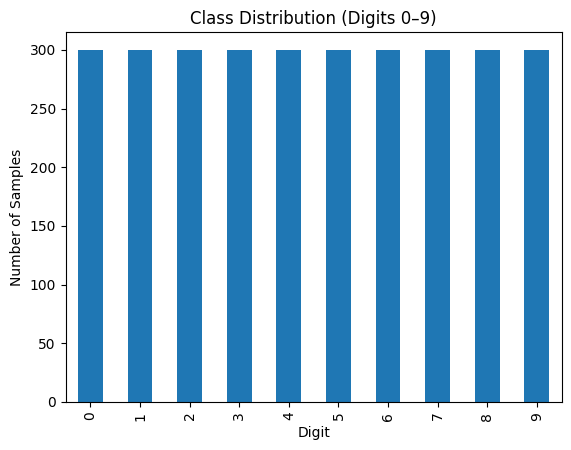

In [9]:
plt.figure()
df["digit"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution (Digits 0–9)")
plt.xlabel("Digit")
plt.ylabel("Number of Samples")
plt.show()

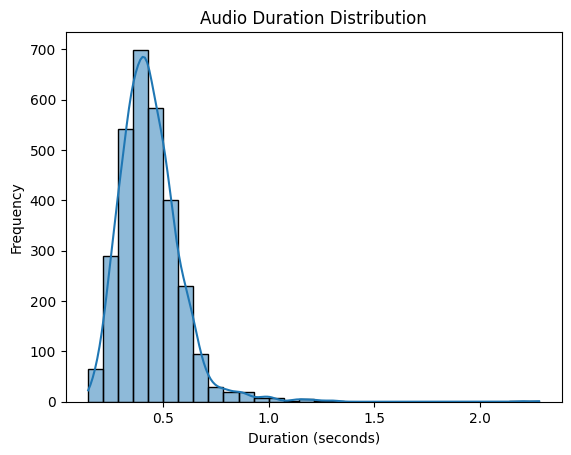

In [156]:
sns.histplot(df["duration"], bins=30, kde=True)
plt.title("Audio Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

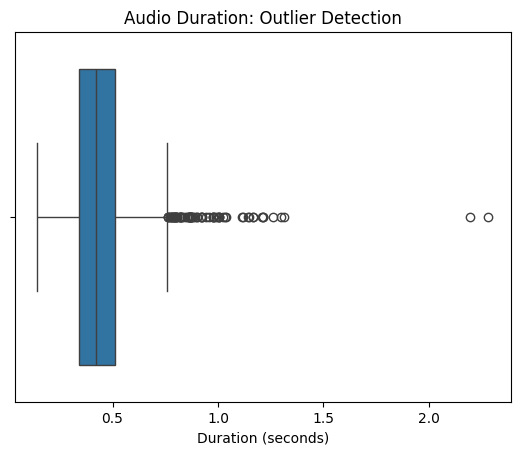

In [152]:
sns.boxplot(x=df["duration"])
plt.title("Audio Duration: Outlier Detection")
plt.xlabel("Duration (seconds)")
plt.show()

In [16]:
df["sample_rate"].value_counts()

sample_rate
8000    3000
Name: count, dtype: int64

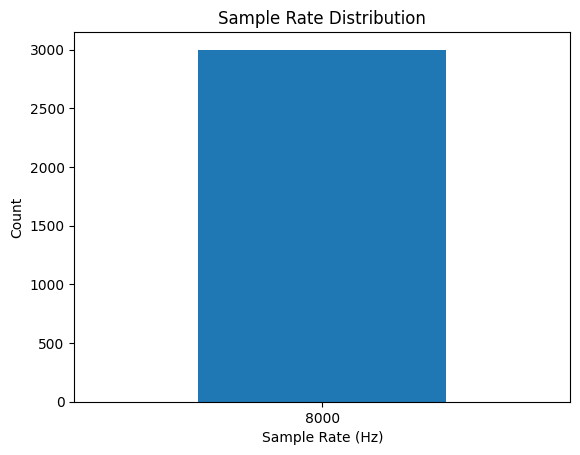

In [18]:
plt.figure()
df["sample_rate"].value_counts().plot(kind="bar")
plt.title("Sample Rate Distribution")
plt.xlabel("Sample Rate (Hz)")
plt.ylabel("Count")
plt.xticks(rotation = 0)
plt.show()

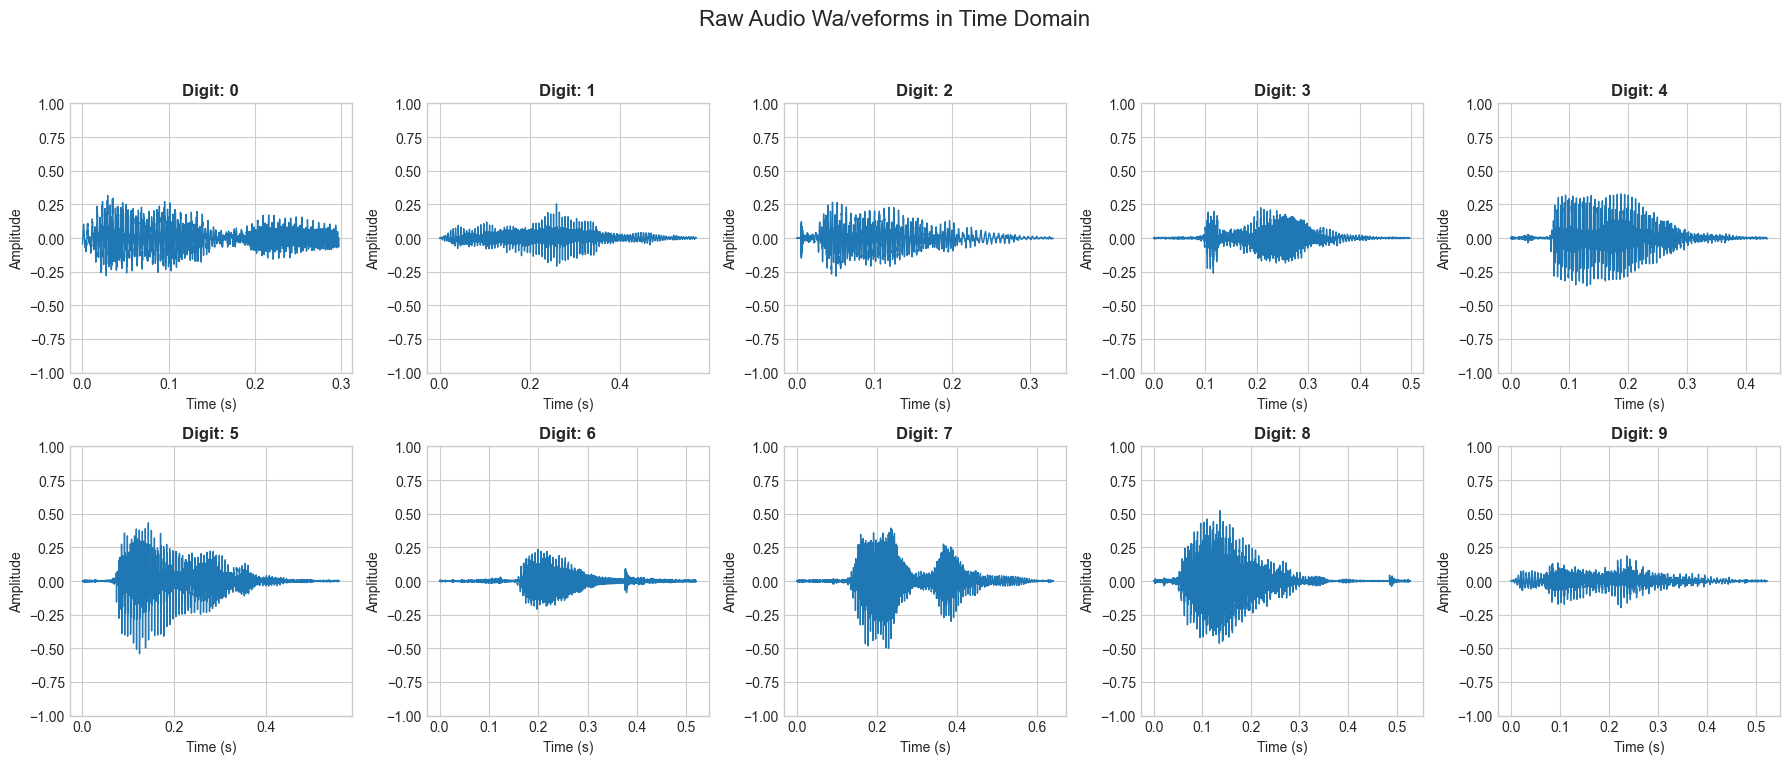

In [212]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for digit in range(10):
    digit_files = [f for f, l in zip(files, labels) if l == digit]
    
    if digit_files:
        file_path = os.path.join(data_dir, digit_files[0])
        y, sr = librosa.load(file_path, sr=8000)
        
        time = np.linspace(0, len(y) / sr, len(y))
        
        axes[digit].plot(time, y, color='#1f77b4', linewidth=1)
        axes[digit].set_title(f'Digit: {digit}', fontsize=12, fontweight='bold')
        axes[digit].set_xlabel('Time (s)', fontsize=10)
        axes[digit].set_ylabel('Amplitude', fontsize=10)
        axes[digit].set_ylim(-1, 1)

plt.suptitle("Raw Audio Wa/veforms in Time Domain", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

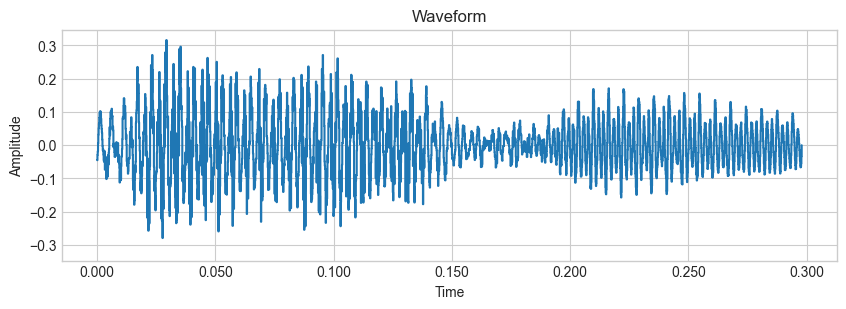

In [214]:
sample_file = os.path.join(data_dir, files[0])
y, sr = librosa.load(sample_file, sr=8000)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

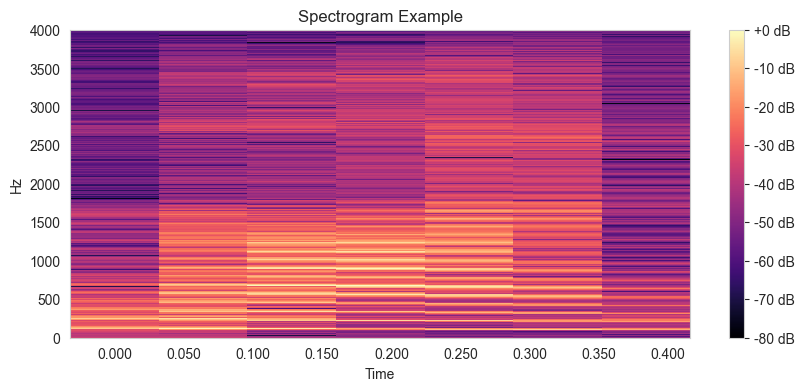

In [178]:
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram Example")
plt.show()

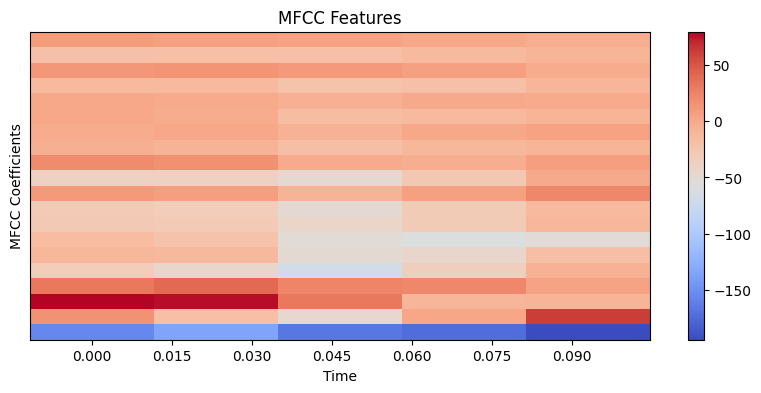

In [24]:
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, x_axis="time")
plt.colorbar()
plt.title("MFCC Features")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.show()

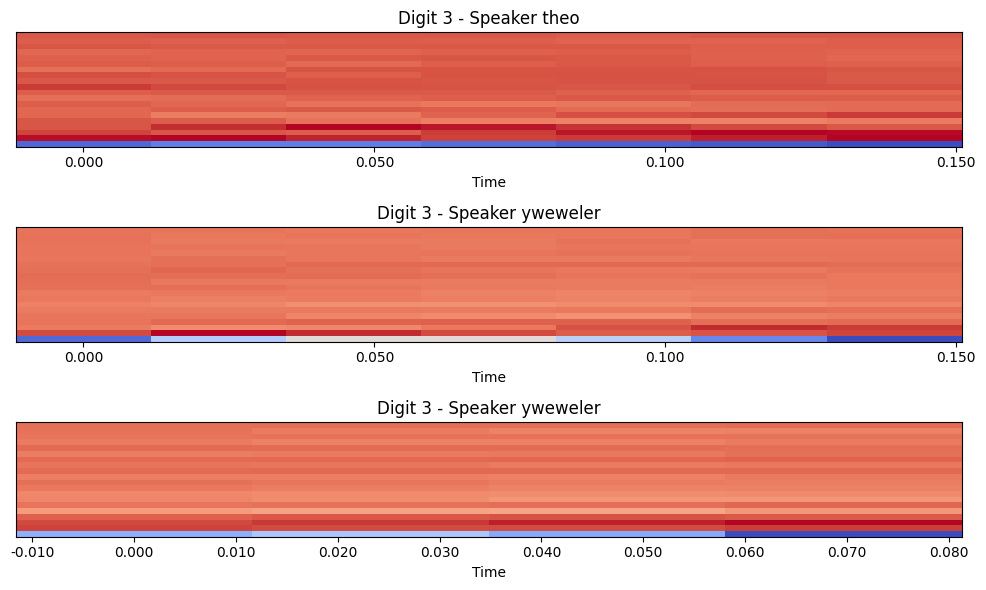

In [26]:
digit_example = "3"
subset = df[df["digit"] == digit_example].sample(3)

plt.figure(figsize=(10, 6))

for i, row in enumerate(subset.itertuples()):
    y, sr = librosa.load(os.path.join(data_dir, row.file), sr=8000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    
    plt.subplot(3, 1, i+1)
    librosa.display.specshow(mfcc, x_axis="time")
    plt.title(f"Digit {digit_example} - Speaker {row.speaker}")

plt.tight_layout()
plt.show()

In [170]:
lengths = []

for file in files:
    y, sr = librosa.load(os.path.join(data_dir, file), sr=8000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    lengths.append(mfcc.shape[1])

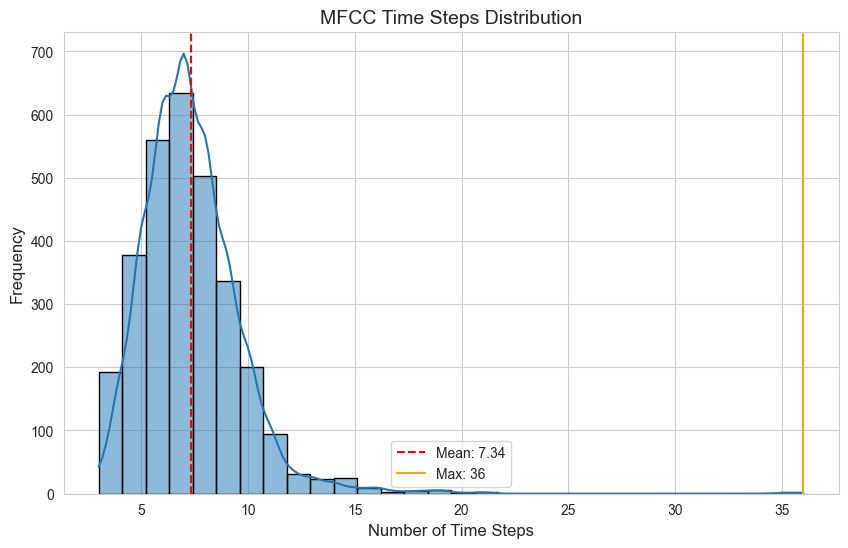

Min MFCC length: 3
Max MFCC length: 36
Median MFCC length: 7.0


In [174]:
plt.figure(figsize=(10, 6))

sns.histplot(lengths, bins=30, kde=True, edgecolor="black")

plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.2f}')
plt.axvline(max(lengths), color='orange', linestyle='-', label=f'Max: {max(lengths)}')

plt.title("MFCC Time Steps Distribution", fontsize=14)
plt.xlabel("Number of Time Steps", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

print(f"Min MFCC length: {min(lengths)}")
print(f"Max MFCC length: {max(lengths)}")
print(f"Median MFCC length: {np.median(lengths)}")

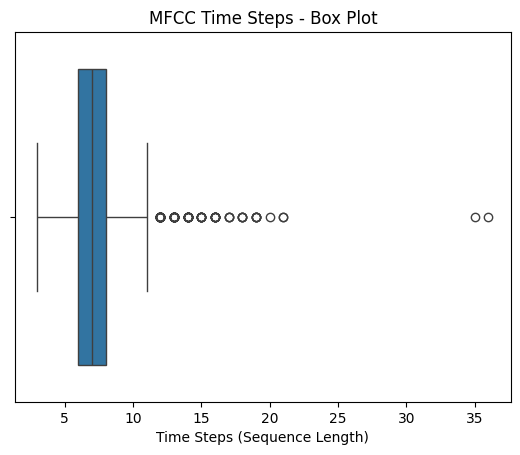

In [34]:
sns.boxplot(x=lengths)
plt.title("MFCC Time Steps - Box Plot")
plt.xlabel("Time Steps (Sequence Length)")
plt.show()

In [36]:
def extract_features_cnn(file_path, n_mfcc=20, max_len=20):
    signal, sr = librosa.load(file_path, sr=8000)
    signal, _ = librosa.effects.trim(signal)
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    
    return mfcc.T

In [42]:
X = np.array([extract_features_cnn(f) for f in file_paths])
y = np.array([os.path.basename(f).split('_')[0] for f in file_paths])

label_encoding = LabelEncoder()
y_encoded = label_encoding.fit_transform(y)
y_categorical = to_categorical(y_encoded)

X = X[..., np.newaxis]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

In [58]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(X_train.shape[1], X_train.shape[2], 1)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),
    
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 18, 18, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 9, 9, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 9, 9, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 3, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 93,962 (367.04 KB)

 Trainable params: 93,962 (367.04 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    epochs=100, batch_size=32, 
    validation_data=(X_test, y_test), 
    callbacks=[early_stop]
)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.1300 - loss: 4.4631 - val_accuracy: 0.2583 - val_loss: 2.1606
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2404 - loss: 2.1239 - val_accuracy: 0.5567 - val_loss: 1.7464
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3688 - loss: 1.7776 - val_accuracy: 0.6500 - val_loss: 1.3109
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4733 - loss: 1.4515 - val_accuracy: 0.7967 - val_loss: 0.8821
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5892 - loss: 1.1464 - val_accuracy: 0.8650 - val_loss: 0.6016
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6350 - loss: 1.0069 - val_accuracy: 0.8750 - val_loss: 0.4969
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6888 - loss: 0.8643 - val_accuracy: 0.9050 - val_loss: 0.3685
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7408 - loss: 0.7302 - val_accuracy: 0.

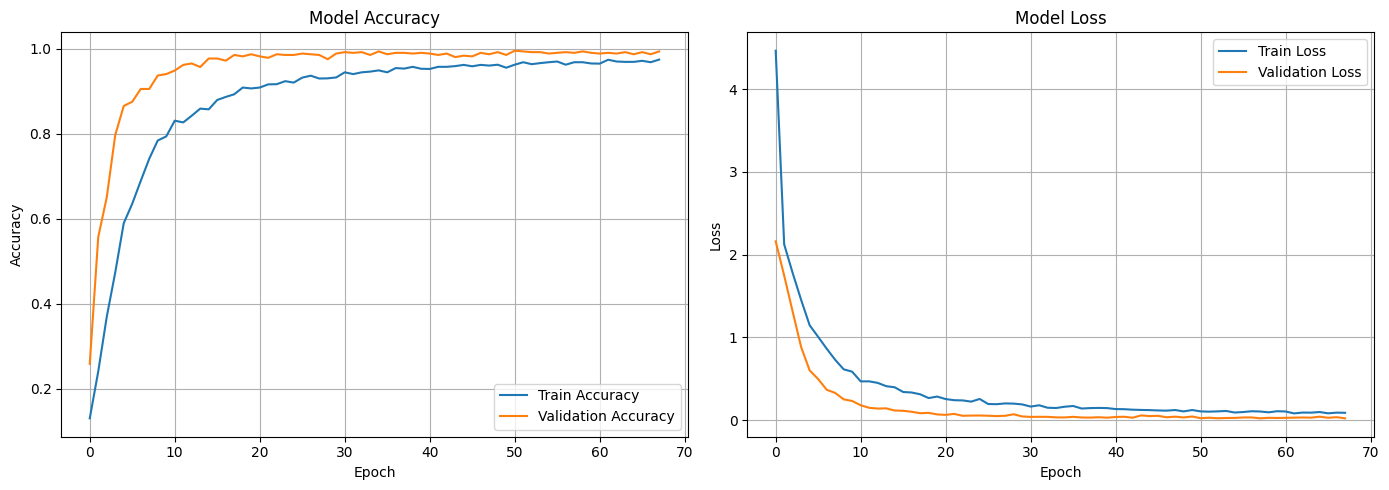

In [76]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [62]:
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true_labels, y_pred_labels))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       1.00      1.00      1.00        60
           2       1.00      0.98      0.99        60
           3       0.95      1.00      0.98        60
           4       1.00      1.00      1.00        60
           5       1.00      0.97      0.98        60
           6       0.97      0.98      0.98        60
           7       1.00      1.00      1.00        60
           8       1.00      0.97      0.98        60
           9       0.98      1.00      0.99        60

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



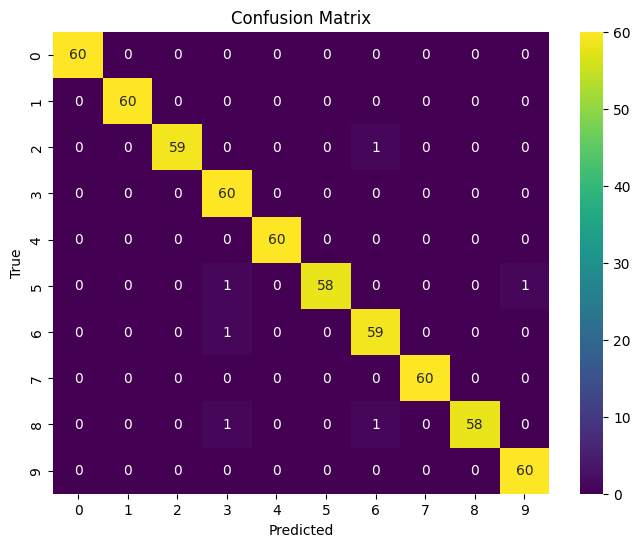

In [64]:
cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [93]:
model.save("final_project.keras")

In [106]:
model = load_model("final_project.keras")

In [218]:
labels = ['0','1','2','3','4','5','6','7','8','9']
le = LabelEncoder()
le.fit(labels)

LabelEncoder()

In [110]:
def preprocess_audio(file_path, sr=8000, n_mfcc=20, max_len=20):
    audio, _ = librosa.load(file_path, sr=sr)
    audio, _ = librosa.effects.trim(audio)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)

    if mfcc.shape[1] < max_len:
        pad = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, ((0,0),(0,pad)), mode="constant")
    else:
        mfcc = mfcc[:, :max_len]

    return mfcc.T[np.newaxis, ..., np.newaxis]

In [128]:
def predict_digit_average(file_path, repeats=5):
    preds = []

    for _ in range(repeats):
        X_new = preprocess_audio(file_path)
        pred = model.predict(X_new, verbose=0)
        preds.append(pred)

    avg_pred = np.mean(preds, axis=0)
    digit = le.inverse_transform([np.argmax(avg_pred)])[0]

    confidence = np.max(avg_pred) * 100
    return digit, confidence

In [130]:
test_paths = [
    r"C:\Users\tayse\free-spoken-digit-dataset\recordings\7_george_15.wav",
    r"C:\Users\tayse\Downloads\7_male.wav",
    r"C:\Users\tayse\Downloads\7_Aysel_Voice.wav"
]

for path in test_paths:
    digit_pred, conf = predict_digit_average(path, repeats=5)

    print(f"File: {os.path.basename(path)}")
    print(f"Predicted digit: {digit_pred}")
    print(f"Confidence: {conf:.2f}%")
    display(Audio(path))
    print("-" * 50)

File: 7_george_15.wav
Predicted digit: 7
Confidence: 100.00%


--------------------------------------------------
File: 7_male.wav
Predicted digit: 7
Confidence: 99.91%


--------------------------------------------------
File: 7_Aysel_Voice.wav
Predicted digit: 7
Confidence: 99.35%


--------------------------------------------------
